# Thesis: Reclaimed Timber in Deep Generative Design
**Notebook ID:** c21_surrogate_model_training  
**Author:** Jasper Cluistra   
**Last Updated:** 2026-04-14

### Surrogate model training script (REFACTORED)
**Goal:** Train a Graph Neural Network surrogate model on structural analysis data to predict beam forces.

**Architecture:** This notebook now uses a modular design:
- **`c21_train.py`**: Core training logic (data loading, processing, training, export)
- **`c21_surrogate_model_training.ipynb`**: Orchestration and interactive visualization

**Usage:**
1. Set environment variables or use defaults (see `c21_train.py`)
2. Run the training cell (Cell 2) → executes complete workflow
3. Run visualization cells (Cells 3-5) → generate diagnostic plots
4. Run evaluation cell (Cell 6) → export metrics

**Inputs:**
- CSV files with structural properties from Grasshopper (node, edge, global data)

**Outputs:**
    bundle = c21_surrogate_io.load_surrogate_bundle()


# TRAINING EXECUTION

All training logic is encapsulated in src/c21_train.py. Run the cell below to execute the complete workflow (data loading -> processing -> training -> export). Parameters are set via environment variables (see src/c21_train.py or set via os.environ before running).


In [1]:
"""
RUN TRAINING WORKFLOW - Single cell execution
This notebook now uses src/c21_train.py for core logic.
"""
import os
import importlib
import pandas as pd
import config
import src.c21_data_pipeline as c21_data_pipeline
import src.c21_train as c21_train

# Always reload so notebook uses latest code edits.
importlib.reload(c21_data_pipeline)
importlib.reload(c21_train)

# Core c21 env (edit these to switch between lean and full schemas).
os.environ.setdefault("C21_DATA_PREFIX", "S19999_D20260418")
os.environ.setdefault("C21_USE_GLOBAL_CSV", "false")

# CSV source files (defaults derived from C21_DATA_PREFIX).
os.environ.setdefault("C21_NODE_CSV", f"v4_node_C6_{os.environ['C21_DATA_PREFIX']}.csv")
os.environ.setdefault("C21_EDGE_CSV", f"v4_edge_C7_{os.environ['C21_DATA_PREFIX']}.csv")
os.environ.setdefault("C21_GLOBAL_CSV", f"v4_global_C4_{os.environ['C21_DATA_PREFIX']}.csv")

# Optional lean feature sets (unset these to let schema auto-detect all available columns).
os.environ.setdefault("C21_NODE_CONTINUOUS_COLS", "x,y,z,Fz")
# Only used when C21_USE_GLOBAL_CSV=true
os.environ.setdefault("C21_GLOBAL_FEATURE_COLS", "Global_Load_Sum,Total_Structural_Volume,Average_Connectivity")

# Auto-detect available node mask columns for this node CSV.
node_preview_path = config.GH_DATA_PATH / os.environ["C21_NODE_CSV"]
node_cols = pd.read_csv(node_preview_path, nrows=1).columns
mask_candidates = ["Tx", "Ty", "Tz", "Rx", "Ry", "Rz", "is_support"]
mask_present = [c for c in mask_candidates if c in node_cols]
if mask_present:
    os.environ["C21_NODE_MASK_COLS"] = ",".join(mask_present)
else:
    os.environ.pop("C21_NODE_MASK_COLS", None)

# Auto-detect available edge feature columns for this edge CSV.
edge_preview_path = config.GH_DATA_PATH / os.environ["C21_EDGE_CSV"]
edge_cols = pd.read_csv(edge_preview_path, nrows=1).columns
edge_candidates = ["Area", "Length", "E", "Iy", "Iz", "J", "EA/L"]
edge_present = [c for c in edge_candidates if c in edge_cols]
if not edge_present:
    raise ValueError("No supported edge feature columns found in edge CSV.")
os.environ["C21_EDGE_FEATURE_COLS"] = ",".join(edge_present)

# Hyperparameter defaults (mirrors src/c21_train.py defaults).
os.environ.setdefault("C21_LEARNING_RATE", "0.0005")
os.environ.setdefault("C21_EPOCHS", "100")
os.environ.setdefault("C21_BATCH_SIZE", "16")
os.environ.setdefault("C21_HIDDEN_DIM", "128")
os.environ.setdefault("C21_MODEL_VARIANT", "v1")
os.environ.setdefault("C21_DROPOUT_P", "0.1")
os.environ.setdefault("C21_WEIGHT_DECAY", "0.0")
os.environ.setdefault("C21_LOSS_TYPE", "mse")
os.environ.setdefault("C21_HUBER_BETA", "1.0")
os.environ.setdefault("C21_USE_LR_SCHEDULER", "false")
os.environ.setdefault("C21_LR_SCHEDULER_FACTOR", "0.5")
os.environ.setdefault("C21_LR_SCHEDULER_PATIENCE", "2")
os.environ.setdefault("C21_LR_SCHEDULER_METRIC", "r2")
os.environ.setdefault("C21_LR_SCHEDULER_MIN_LR", "1e-6")
os.environ.setdefault("C21_USE_VIRTUAL_NODE", "true")
os.environ.setdefault("C21_EDGE_WISE_TARGET_SCALING", "false")
os.environ.setdefault("C21_TRAIN_SPLIT_RATIO", "0.8")
os.environ.setdefault("C21_RANDOM_SEED", "42")

# Training controls
os.environ.setdefault("C21_USE_EARLY_STOPPING", "true")
os.environ.setdefault("C21_EARLY_STOPPING_PATIENCE", "8")
os.environ.setdefault("C21_EARLY_STOPPING_METRIC", "r2")
os.environ.setdefault("C21_EVAL_EVERY", "2")

# Execute training (runs src/c21_train.py main workflow)
results = c21_train.main()

# Extract results for visualization cells below
model = results["model"]
device = results["device"]
epoch_history = results["epoch_history"]
train_loss_history = results["train_loss_history"]
final_val_r2 = results["final_val_r2"]
edge_target_scaler = results["scalers"]["edge_target"]
train_loader = results["train_loader"]
test_loader = results["test_loader"]
schema = results["schema"]
params = results["params"]

print("Training workflow complete. Results available for visualization.")
print(f"use_global_csv={params['use_global_csv']}")
print(f"node_features={schema.node_continuous_cols + schema.node_mask_cols + schema.node_virtual_cols}")
print(f"edge_features={schema.edge_feature_cols}")
print(f"global_features={schema.global_feature_cols}")

System loaded successfully.

Code is running locally from: thesis_generative_timber
Data connected to OneDrive: 2.2 - 2.4

GH data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\01_grasshopper_data
Raw data directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\30_Data_Inventory\02_raw_data
Export directory: C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports



c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


c21 SURROGATE MODEL TRAINING

Device: cuda

Parameters loaded:
- fast_mode=False (default)
- lr=0.0005, epochs=100, batch=16
- data: node=v4_node_C6_S19999_D20260418.csv, edge=v4_edge_C7_S19999_D20260418.csv, global=v4_global_C4_S19999_D20260418.csv (enabled=False)
- hidden_dim=128, weight_decay=0.0
- model_variant=v1, dropout_p=0.1
- loss_type=mse, huber_beta=1.0
- eval_every=2, num_workers=0
- early_stopping: patience=8, metric=r2
- Run ID: ID20260418_215020

1. Loading multi-source dataset...

--- DATA VALIDATION ---
Node rows:         260000
Edge rows:         640000
Samples:           20000
Node count:        13
Edge count:        32
Node features:     ('x', 'y', 'z', 'Fz', 'is_virtual')
Edge features:     ('Area', 'Length')
Global features:   ()
edge_index shape:  (2, 64)
Validation successful. Multi-source data loaded correctly.

Processing and normalizing data...
Dataset ready! Train: 16000 graphs. Test: 4000 graphs.

Training from scratch.
Model: TrussEdgeNNConv on cuda

🚀 Sta

C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\src\c21_model_evaluation.py:149: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\IPython\core\events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
c:\Users\Jasper\Documents\PyEnvs\thesis_home_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


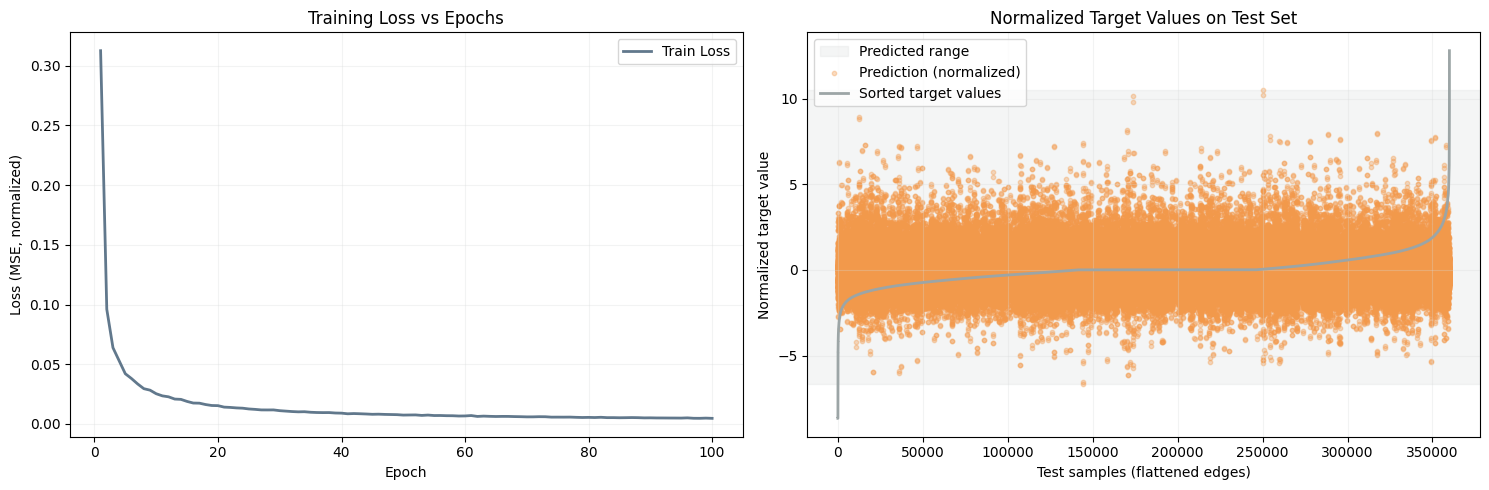

In [2]:
# Plot: Loss curve + normalized target distribution on test set
import os
import importlib
import numpy as np
import torch
import src.c21_train as c21_train
from c21_model_evaluation import build_training_visuals_figure

# Recover variables from prior training output when available.
if "model" not in globals() or "test_loader" not in globals() or "device" not in globals():
    if "results" in globals() and isinstance(results, dict):
        model = results["model"]
        device = results["device"]
        epoch_history = results["epoch_history"]
        train_loss_history = results["train_loss_history"]
        test_loader = results["test_loader"]
    else:
        print("Model not found in memory. Running training workflow now...")
        importlib.reload(c21_train)
        os.environ.setdefault("C21_USE_EARLY_STOPPING", "true")
        os.environ.setdefault("C21_EARLY_STOPPING_PATIENCE", "8")
        os.environ.setdefault("C21_EARLY_STOPPING_METRIC", "r2")
        results = c21_train.main()
        model = results["model"]
        device = results["device"]
        epoch_history = results["epoch_history"]
        train_loss_history = results["train_loss_history"]
        test_loader = results["test_loader"]

model.eval()
all_test_targets_scaled = []
all_test_preds_scaled = []

with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(device, non_blocking=True)
        out = model(
            batch.x,
            batch.edge_index,
            edge_attr=batch.edge_attr,
            batch=batch.batch,
            u=batch.u,
        )
        all_test_targets_scaled.append(batch.y_edge.detach().cpu().numpy())
        all_test_preds_scaled.append(out.detach().cpu().numpy())

test_targets_scaled = np.concatenate(all_test_targets_scaled, axis=0) if len(all_test_targets_scaled) > 0 else np.array([])
test_preds_scaled = np.concatenate(all_test_preds_scaled, axis=0) if len(all_test_preds_scaled) > 0 else np.array([])

training_visuals_fig = build_training_visuals_figure(
    epoch_history,
    train_loss_history,
    test_targets_scaled,
    test_preds_scaled,
)

# EVALUATION & VISUALIZATION FOR OVER/UNDERFITTING

In [3]:
"""Setup for visualization cells - prepare environment and imports"""
import matplotlib.pyplot as plt
import numpy as np
import torch
import config
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Environment ready for visualization.")


Environment ready for visualization.


In [4]:
# Diagnostic: Check masking statistics
from src.c21_diagnostic_verify_r2 import summarize_edge_masking

if "train_loader" not in globals():
    if "results" in globals() and isinstance(results, dict) and "train_loader" in results:
        train_loader = results["train_loader"]
    else:
        raise NameError("train_loader not found. Run the training cell first (Cell 3).")

print("=" * 60)
print("EDGE MASKING STATISTICS")
print("=" * 60)

mask_summary = summarize_edge_masking(train_loader)

if mask_summary["first_batch"] is not None:
    first = mask_summary["first_batch"]
    print(f"\nFirst batch: {first['kept']} kept / {first['masked']} masked / {first['total']} total edges")

if mask_summary["has_mask"]:
    print("\nTraining set aggregate:")
    print(f"  Total edges: {mask_summary['total_edges']}")
    print(f"  Kept (structural):  {mask_summary['total_kept']:,} ({mask_summary['pct_kept']:.1f}%)")
    print(f"  Masked (virtual):   {mask_summary['total_masked']:,} ({mask_summary['pct_masked']:.1f}%)")

    if mask_summary["pct_masked"] > 50:
        print(f"\nWarning: {mask_summary['pct_masked']:.1f}% of edges are virtual (masked out).")
        print("   This happens when use_virtual_node=True, which adds a synthetic node")
        print("   for global context propagation. These virtual edges are intentionally")
        print("   filtered from the loss and metrics.")
    else:
        print(f"\nOnly {mask_summary['pct_masked']:.1f}% masked edges (minor overhead).")
else:
    print("No mask found in batches (all edges included by default).")

print("=" * 60)


EDGE MASKING STATISTICS

First batch: 1024 kept / 416 masked / 1440 total edges

Training set aggregate:
  Total edges: 1440000
  Kept (structural):  1,024,000 (71.1%)
  Masked (virtual):   416,000 (28.9%)

Only 28.9% masked edges (minor overhead).


In [5]:
# Run R2 legitimacy diagnostic report
from src.c21_diagnostic_verify_r2 import main as run_c21_r2_diagnostic

run_c21_r2_diagnostic()

DIAGNOSTIC: Is R2 around 0.99 plausible?

1) Target spread
----------------------------------------------------------------------
Count:   640,000
Min:     -231.860
Max:     316.874
Std:     23.166
Range:   548.735

2) Baseline check (predict mean)
----------------------------------------------------------------------
Baseline R2:  0.0000
Baseline MAE: 16.8905

3) Linear signal strength in edge features
----------------------------------------------------------------------
    Area: r=-0.1395 |r|=0.1395
  Length: r=-0.0917 |r|=0.0917
       E: r=-0.0250 |r|=0.0250
      Iy: r=-0.1574 |r|=0.1574
      Iz: r=-0.1063 |r|=0.1063
       J: r=-0.1112 |r|=0.1112
    EA/L: r=-0.0625 |r|=0.0625
Linear model R2 on full dataset: 0.0286

4) Split sanity
----------------------------------------------------------------------
Unique samples: 20,000
Total edge rows: 640,000
Edges per sample (avg): 32.00
Expected training split is graph-level (80/20), which avoids edge-level leakage.

5) Context for yo

Train R2:  0.9958
Test R2:   0.9885
Train MAE: 1.1456 kN
Test MAE:  1.6089 kN
Train RMSE: 1.5449 kN
Test RMSE:  2.5554 kN



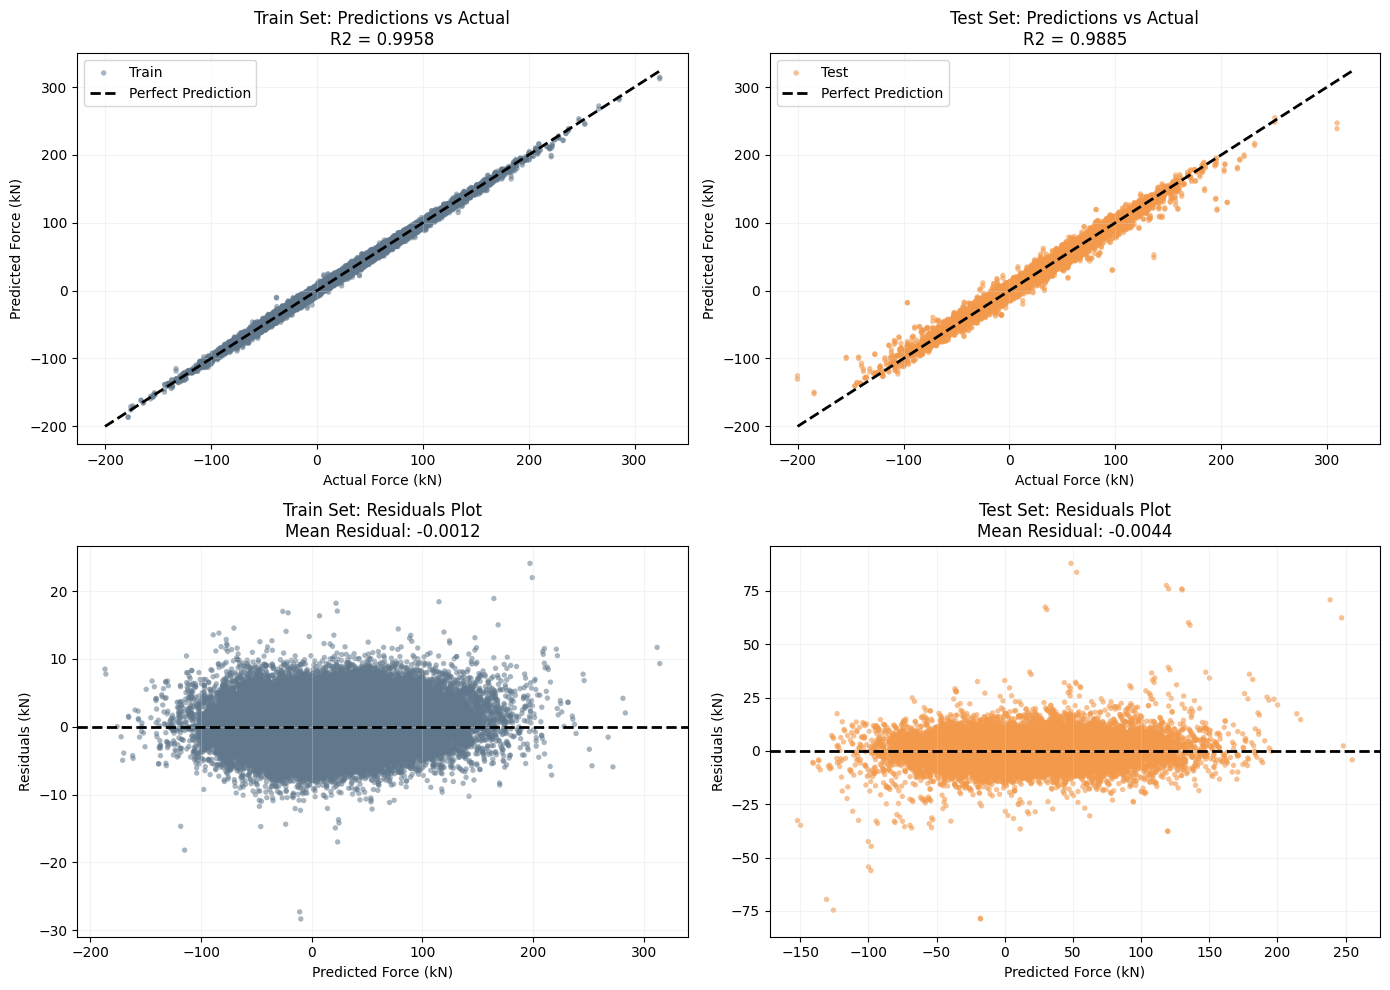

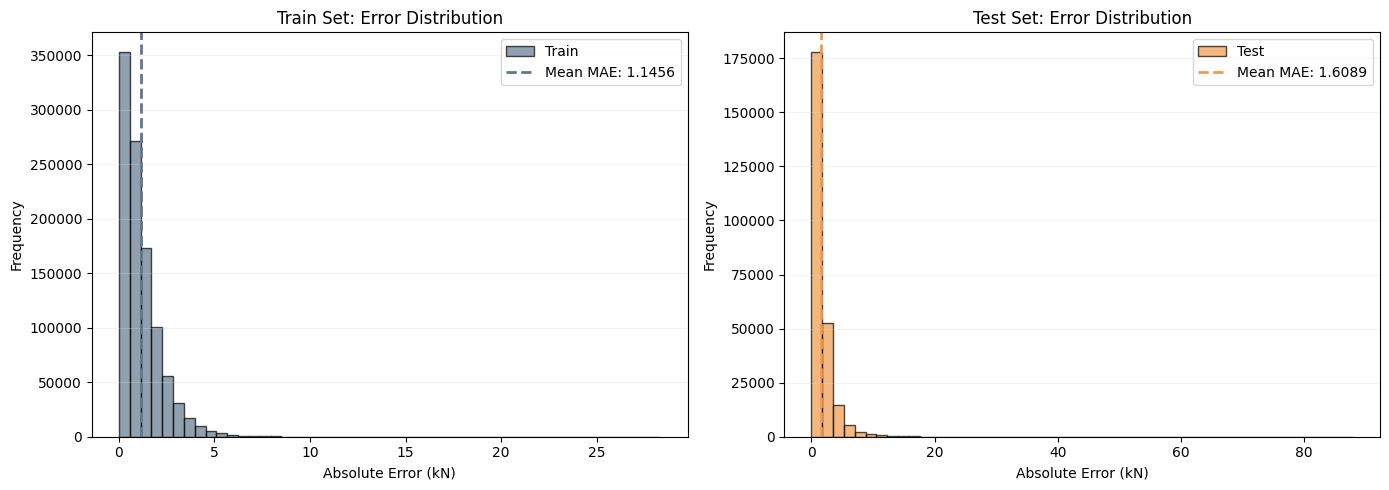

In [6]:
# Predictions vs Actual + Residual diagnostics (Train/Test)
import numpy as np
from src.c21_diagnostic_verify_r2 import collect_preds_trues_original, drop_non_finite_pairs, compute_split_metrics
from c21_model_evaluation import build_pred_residual_figure, build_error_distribution_figure

# Collect predictions in original kN scale
train_preds_original, train_trues_original = collect_preds_trues_original(
    train_loader,
    model,
    device,
    edge_target_scaler,
)
test_preds_original, test_trues_original = collect_preds_trues_original(
    test_loader,
    model,
    device,
    edge_target_scaler,
)

# Remove NaN/Inf values pairwise before residuals/metrics
train_trues_original, train_preds_original = drop_non_finite_pairs(
    train_trues_original,
    train_preds_original,
    "train",
)
test_trues_original, test_preds_original = drop_non_finite_pairs(
    test_trues_original,
    test_preds_original,
    "test",
)

# Residuals and metrics
train_residuals = train_trues_original - train_preds_original
test_residuals = test_trues_original - test_preds_original

train_metrics = compute_split_metrics(train_trues_original, train_preds_original)
test_metrics = compute_split_metrics(test_trues_original, test_preds_original)

train_r2 = train_metrics["r2"]
test_r2 = test_metrics["r2"]
train_mae = train_metrics["mae"]
test_mae = test_metrics["mae"]
train_rmse = train_metrics["rmse"]
test_rmse = test_metrics["rmse"]

print(f"Train R2:  {train_r2:.4f}")
print(f"Test R2:   {test_r2:.4f}")
print(f"Train MAE: {train_mae:.4f} kN")
print(f"Test MAE:  {test_mae:.4f} kN")
print(f"Train RMSE: {train_rmse:.4f} kN")
print(f"Test RMSE:  {test_rmse:.4f} kN\n")

pred_residuals_fig = build_pred_residual_figure(
    train_trues_original,
    train_preds_original,
    test_trues_original,
    test_preds_original,
    train_r2,
    test_r2,
)

# Error distribution plots
error_dist_fig = build_error_distribution_figure(
    train_residuals,
    test_residuals,
    train_mae,
    test_mae,
 )


In [7]:
# Final evaluation export
import importlib
from c21_model_evaluation import save_evaluation
from c00_naming import build_model_artifact_stem

# Determine fit status
r2_gap = train_r2 - test_r2
if train_r2 < 0.7 and test_r2 < 0.7:
    status = "underfitting"
elif r2_gap > 0.05:
    status = "overfitting"
else:
    status = "good_fit"

metrics = {
    "train_r2": train_r2,
    "test_r2": test_r2,
    "train_mae": train_mae,
    "test_mae": test_mae,
    "train_rmse": train_rmse,
    "test_rmse": test_rmse,
    "r2_gap": float(r2_gap),
}

# Optional training figure from the first visualization cell
training_visuals_fig_local = training_visuals_fig if "training_visuals_fig" in globals() else None

# Keep ID consistent with model/scaler exports in 01_surrogate_models
model_artifact_stem = build_model_artifact_stem(
    params["run_id"],
    params["learning_rate"],
    params["epochs"],
    final_val_r2,
)

architecture_summary = {
    "model_class": "TrussEdgeNNConv",
    "node_in_dim": len(schema.node_continuous_cols) + len(schema.node_mask_cols),
    "edge_in_dim": len(schema.edge_feature_cols),
    "global_in_dim": len(schema.global_feature_cols),
    "selected_node_continuous_cols": tuple(schema.node_continuous_cols),
    "selected_node_mask_cols": tuple(schema.node_mask_cols),
    "selected_node_virtual_cols": tuple(getattr(schema, "node_virtual_cols", ())),
    "selected_edge_feature_cols": tuple(schema.edge_feature_cols),
    "selected_global_feature_cols": tuple(schema.global_feature_cols),
    "node_features": tuple(schema.node_continuous_cols) + tuple(schema.node_mask_cols) + tuple(getattr(schema, "node_virtual_cols", ())),
    "edge_features": tuple(schema.edge_feature_cols),
    "global_features": tuple(schema.global_feature_cols),
    "hidden_dim": params["hidden_dim"],
    "edge_count": schema.edge_count,
    "device": str(device),
    "dataset_sources": {
        "node": params["node_csv"],
        "edge": params["edge_csv"],
        "global": params["global_csv"],
    },
}

experiment_notes = (
    f"USE_PRETRAINED={params['use_pretrained']}; "
    f"lr={params['learning_rate']}; epochs={params['epochs']}; "
    f"batch_size={params['batch_size']}; hidden_dim={params['hidden_dim']}; "
    f"weight_decay={params['weight_decay']}"
)

# Get epoch metrics history from training results
epoch_metrics_history = results.get("epoch_metrics_history", []) if "results" in globals() else []

# Save evaluation
saved_files = save_evaluation(
    model_prefix=model_artifact_stem,
    dataset_name=f"{params['node_csv']} | {params['edge_csv']} | {params['global_csv']}",
    metrics=metrics,
    pred_residuals_fig=pred_residuals_fig,
    error_dist_fig=error_dist_fig,
    training_visuals_fig=training_visuals_fig_local,
    node_count=schema.node_count,
    edge_count=schema.edge_count,
    export_path=config.SM_DATA_PATH,
    status=status,
    run_id=params["run_id"],
    artifact_stem=model_artifact_stem,
    feature_count=architecture_summary["node_in_dim"] + architecture_summary["edge_in_dim"] + architecture_summary["global_in_dim"],
    learning_rate=params["learning_rate"],
    epochs=params["epochs"],
    eval_every=params.get("eval_every"),
    final_val_r2=final_val_r2,
    strict_dataset_label=f"{params['node_csv']} | {params['edge_csv']} | {params['global_csv']}",
    source_dataset_path=str(config.GH_DATA_PATH / params["edge_csv"]),
    architecture_summary=architecture_summary,
    experiment_notes=experiment_notes,
    train_split_ratio=params["train_split_ratio"],
    random_seed=params["random_seed"],
    source_notebook="c21_surrogate_model_training.ipynb",
    epoch_metrics_history=epoch_metrics_history,
)

print(f"\n✅ Evaluation exported:")
for f in saved_files:
    print(f"  - {f}")


Saving evaluation results for: ID20260418_215020_LR0.0005_EP100_R0.99

Predictions plot saved: 01_predictions_residuals_20260418_224631.png
Error distribution saved: 02_error_distribution_20260418_224631.png


C:\Users\Jasper\Documents\PyRepo\thesis_generative_timber\src\c21_model_evaluation.py:488: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  training_visuals_fig.savefig(training_plot_path, dpi=150, bbox_inches='tight')


Training diagnostics saved: 03_training_diagnostics_20260418_224631.png
Epoch history saved: epoch_history_20260418_224631.csv
Architecture summary saved: model_architecture_20260418_224631.txt
Manifest saved: run_manifest_20260418_224631.json
Experiment card saved: experiment_card_20260418_224631.md
README saved: README.md

All evaluation files saved to:
   C:\Users\Jasper\OneDrive\06 Building Technology TU\2.2 - 2.4\60_Research_Exports\02_surrogate_model_data\ID20260418_215020_LR0.0005_EP100_R0.99_F6


✅ Evaluation exported:
  - pred_residuals_plot
  - error_dist_plot
  - training_diagnostics_plot
  - epoch_history_csv
  - architecture_summary
  - manifest
  - experiment_card
  - readme


## Interpretation Guide

### What to look for:

**OVERFITTING** 🔴 (Train performs much better than Test):
- Train R² >> Test R² (gap > 0.05)
- Train residuals are much smaller than test residuals
- Test error histogram has a heavier right tail
- Predictions vs Actual scatter: train points closer to red line than test points

**UNDERFITTING** 🔴 (Both train and test perform poorly):
- Both R² scores are low (< 0.7)
- Both residuals show large systematic patterns
- Both predictions scatter far from the red diagonal line
- High MAE/RMSE on both train and test

**GOOD FIT** ✅ (Train and Test perform similarly):
- Train and Test R² are close (gap < 0.05)
- Both residuals are centered around 0 with similar spread
- Both scatter plots show points close to diagonal line
- Error distributions are similar and centered

### Remedies:

If **Overfitting**:
- **Gather more training data** (most effective long-term solution—model memorizes less with more diverse samples)
- Add dropout layers to the model
- Increase weight decay (L2 regularization)
- Use early stopping on validation loss
- Try reducing model hidden_dim (e.g., 128 → 64)

If **Underfitting**:
- Increase hidden_dim (e.g., 128 → 256)
- Add more GNN layers
- Train for more epochs
- Check if the model has enough capacity for the problem

If **Good Fit**: ✅ Deploy and use in downstream tasks!

## Surrogate feature-importance analysis

In [ ]:
from pathlib import Path
import config
from src import c21_surrogate_io, c21_train
from src.c21_feature_ablation import run_from_training_results

if "results" not in globals() or not isinstance(results, dict):
    bundle = c21_surrogate_io.load_surrogate_bundle()
    manifest = bundle.get("run_manifest") or {}
    dataset_sources = manifest.get("dataset_sources") or {}

    params = c21_train.load_parameters(device=bundle["device"])

    params.update({
        "node_csv": dataset_sources.get("node", params["node_csv"]),
        "edge_csv": dataset_sources.get("edge", params["edge_csv"]),
        "global_csv": dataset_sources.get("global", params["global_csv"]),
        "use_global_csv": bool(manifest.get("use_global_csv", params["use_global_csv"])),
        "selected_node_continuous_cols": tuple(manifest.get("selected_node_continuous_cols") or ()),
        "selected_node_mask_cols": tuple(manifest.get("selected_node_mask_cols") or ()),
        "selected_edge_feature_cols": tuple(manifest.get("selected_edge_feature_cols") or ()),
        "selected_global_feature_cols": tuple(manifest.get("selected_global_feature_cols") or ()),
        "use_virtual_node": bool(manifest.get("use_virtual_node", params["use_virtual_node"])),
        "edge_wise_target_scaling": bool(manifest.get("edge_wise_target_scaling", params["edge_wise_target_scaling"])),
    })

    df_node, df_edge, df_global, schema, sample_ids, edge_index = c21_train.load_data(params)
    train_loader, test_loader, node_scaler, edge_feature_scaler, edge_target_scaler, global_feature_scaler, schema = c21_train.process_data(
        df_node,
        df_edge,
        df_global,
        schema,
        sample_ids,
        edge_index,
        params,
    )

    results = {
        "model": bundle["model"],
        "device": bundle["device"],
        "schema": schema,
        "test_loader": test_loader,
        "scalers": {"edge_target": edge_target_scaler},
    }

feature_ablation_report = run_from_training_results(
    results=results,
    sample_count=100,
    seed=int(params.get("random_seed", 42)),
    output_csv_path=Path(config.SM_EXPORT_PATH) / "feature_ablation_report.csv",
)

display(feature_ablation_report)
print("Top 10 features by mean absolute prediction change:")
display(
    feature_ablation_report[[
        "feature_name",
        "feature_group",
        "mean_abs_prediction_change_kn",
        "mean_prediction_difference_kn",
        "mean_abs_prediction_change_pct",
        "pearson_r_target_mean_abs",
        "spearman_r_target_mean_abs",
    ]].head(10)
 )

Loaded surrogate prefix: ID20260418_215020_LR0.0005_EP100_R0.99
Device: cpu
Model: ID20260418_215020_LR0.0005_EP100_R0.99_surrogate_model.pt
Model variant: v1
1. Loading multi-source dataset...

--- DATA VALIDATION ---
Node rows:         260000
Edge rows:         640000
Samples:           20000
Node count:        13
Edge count:        32
Node features:     ('x', 'y', 'z', 'Fz', 'is_virtual')
Edge features:     ('Area', 'Length')
Global features:   ()
edge_index shape:  (2, 64)
Validation successful. Multi-source data loaded correctly.

Processing and normalizing data...
Dataset ready! Train: 16000 graphs. Test: 4000 graphs.



,feature_name,feature_group,pearson_r_target_mean_abs,spearman_r_target_mean_abs,mean_abs_prediction_change_kn,mean_abs_prediction_change_pct,mean_target_mean_abs_kn,mean_pred_baseline_kn,mean_pred_ablated_kn,n_samples,rank
0,z,node_continuous,-0.108060,0.021092,46.686367,870.704773,16.937899,5.361906,46.515522,100,1
1,Fz,node_continuous,-0.030841,-0.089013,16.571663,309.062927,16.937899,5.361906,9.569922,100,2
2,Length,edge,-0.632615,-0.694269,7.158916,133.514404,16.937899,5.361906,4.966226,100,3
3,y,node_continuous,0.162205,0.118575,1.271839,23.719912,16.937899,5.361906,5.054753,100,4
4,x,node_continuous,0.114752,0.091302,1.159541,21.625546,16.937899,5.361906,5.129661,100,5
5,Area,edge,-0.103112,-0.062359,0.797211,14.868063,16.937899,5.361906,5.379730,100,6


Top 10 features by mean absolute prediction change:


,feature_name,feature_group,mean_abs_prediction_change_kn,mean_abs_prediction_change_pct,pearson_r_target_mean_abs,spearman_r_target_mean_abs
0,z,node_continuous,46.686367,870.704773,-0.108060,0.021092
1,Fz,node_continuous,16.571663,309.062927,-0.030841,-0.089013
2,Length,edge,7.158916,133.514404,-0.632615,-0.694269
3,y,node_continuous,1.271839,23.719912,0.162205,0.118575
4,x,node_continuous,1.159541,21.625546,0.114752,0.091302
5,Area,edge,0.797211,14.868063,-0.103112,-0.062359
